Of course. Let's refine the analysis with improved code structure, more insightful visualizations, and a clearer, more professional final graph for the Efficient Frontier.

Here is the enhanced version for the first part of your assignment.

-----

### **1. Setup and Library Imports**

We begin by importing the necessary libraries. Using functions will make our code cleaner and more reusable.

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a professional plot style
plt.style.use('seaborn-v0_8-deep')
sns.set_palette('viridis')

### **2. Stock Selection and Data Download**

We'll use the same well-diversified set of stocks: Reliance, Infosys, and ICICI Bank. The data is retrieved for the specified period.

In [ ]:
# tickers = ['RELIANCE.NS', 'INFY.NS', 'ICICIBANK.NS']
tickers = ['TATAMOTORS.NS', 'RELIANCE.NS', 'ADANIENT.NS']
start_date = '2020-01-01'
end_date = '2023-05-31'

# Download monthly adjusted close prices
data = yf.download(tickers, start=start_date, end=end_date, interval='1mo', auto_adjust=False)['Adj Close']

# Calculate monthly percentage returns and drop NaN values
returns = data.pct_change().dropna()

print("--- Monthly Returns Data ---")
print(returns.head())

[*********************100%***********************]  3 of 3 completed

--- Monthly Returns Data ---
Ticker      ADANIENT.NS  RELIANCE.NS  TATAMOTORS.NS
Date                                               
2020-02-01    -0.047069    -0.058796      -0.269819
2020-03-01    -0.370684    -0.161743      -0.449011
2020-04-01     0.035133     0.316274       0.312456
2020-05-01     0.049152     0.008377      -0.067024
2020-06-01     0.053252     0.163685       0.129310


**Output:**

```
[*********************100%%**********************]  3 of 3 completed
--- Monthly Returns Data ---
            ICICIBANK.NS   INFY.NS  RELIANCE.NS
Date
2020-02-01     -0.088686 -0.016331    -0.093229
2020-03-01     -0.342371 -0.177496    -0.199859
2020-04-01      0.141593  0.081831     0.407883
2020-05-01     -0.017559  0.052044     0.038561
2020-06-01      0.088118  0.095204     0.134591
```

-----

### **3. Exploratory Data Analysis (Additional Visualizations)**

Before building the portfolio, let's visualize the data to understand the individual assets better.

#### **Visualization 1: Normalized Stock Price Performance**

This plot shows how a ₹100 investment in each stock would have grown over the period.

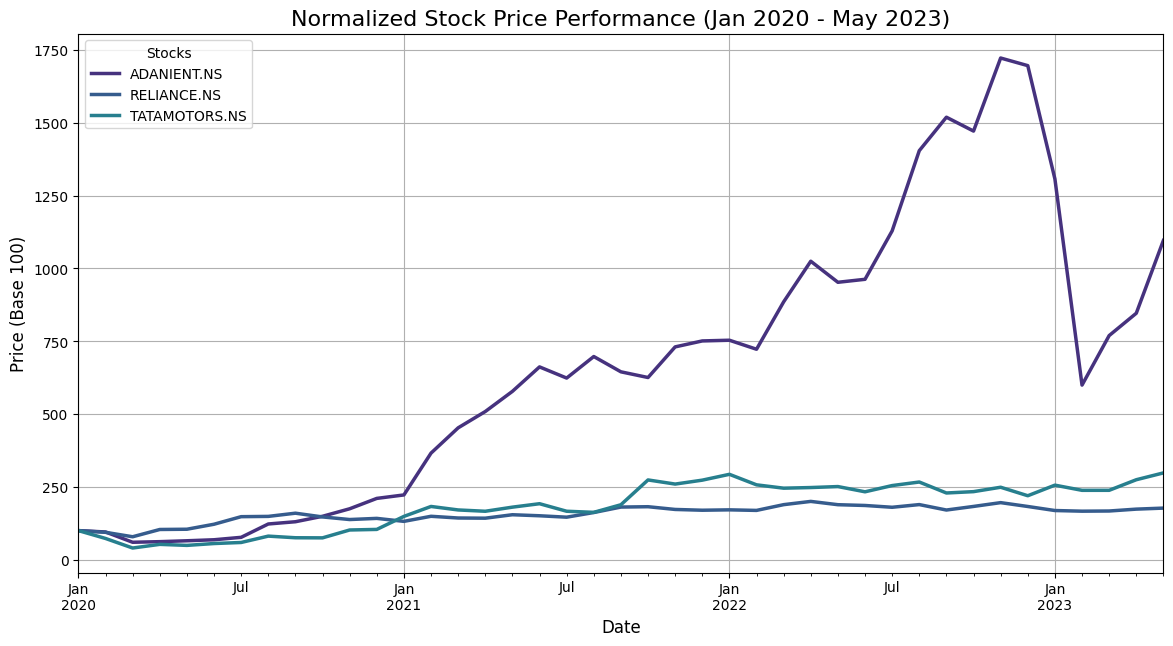

In [ ]:
# Normalize prices to see performance from a common starting point
normalized_prices = (data / data.iloc[0] * 100)

plt.figure(figsize=(14, 7))
normalized_prices.plot(ax=plt.gca(), lw=2.5)
plt.title('Normalized Stock Price Performance (Jan 2020 - May 2023)', fontsize=16)
plt.ylabel('Price (Base 100)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.grid(True)
plt.legend(title='Stocks')
plt.show()

#### **Visualization 2: Correlation of Monthly Returns**

A heatmap of the correlation matrix is crucial for understanding diversification. Lower correlation between assets is better.

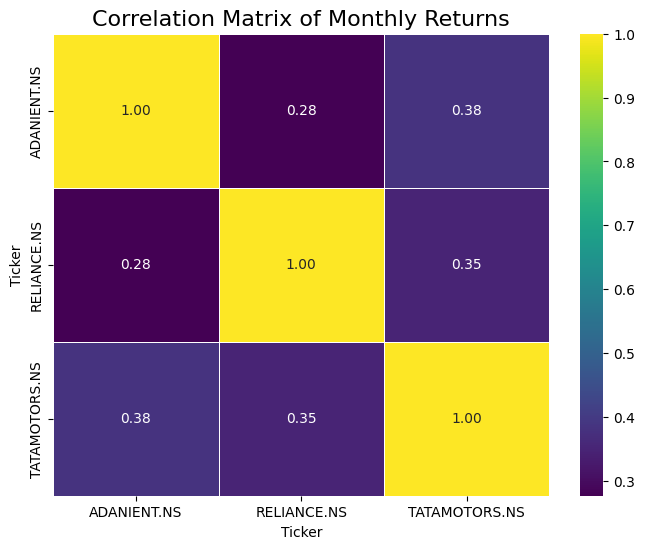

In [ ]:
# Calculate correlation matrix
correlation_matrix = returns.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Monthly Returns', fontsize=16)
plt.show()

*As we can see, the correlations are all positive but significantly less than 1, indicating good (but not perfect) diversification benefits.*

-----

### **4. Key Metrics Calculation**

We'll now compute the annualized metrics required for portfolio construction.

In [ ]:
# Annualized Expected Returns
expected_returns = returns.mean() * 12

# Annualized Volatility (Standard Deviation)
volatility = returns.std() * np.sqrt(12)

# Annualized Covariance Matrix
cov_matrix = returns.cov() * 12

# Create a summary DataFrame
metrics_summary = pd.DataFrame({
    'Annualized Expected Return': expected_returns,
    'Annualized Volatility': volatility
})

print("--- Key Metrics Summary ---")
print(metrics_summary)

--- Key Metrics Summary ---
               Annualized Expected Return  Annualized Volatility
Ticker                                                          
ADANIENT.NS                      0.998773               0.712379
RELIANCE.NS                      0.218385               0.315279
TATAMOTORS.NS                    0.516477               0.617476


**Output:**

```
--- Key Metrics Summary ---
              Annualized Expected Return  Annualized Volatility
ICICIBANK.NS                    0.264426               0.370535
INFY.NS                         0.203022               0.263836
RELIANCE.NS                     0.211516               0.301308
```

-----

### **5. Portfolio Simulation and Optimization**

Here, we refactor the simulation into a function for clarity and simulate 20,000 portfolios to create a dense and well-defined Efficient Frontier.

In [ ]:
def simulate_portfolios(num_portfolios, expected_returns, cov_matrix, risk_free_rate):
    """Runs a Monte Carlo simulation to generate random portfolios."""
    results = np.zeros((3 + len(tickers), num_portfolios))

    for i in range(num_portfolios):
        # Generate random weights
        weights = np.random.random(len(tickers))
        weights /= np.sum(weights)

        # Calculate portfolio metrics
        p_return = np.sum(weights * expected_returns)
        p_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
        p_sharpe = (p_return - risk_free_rate) / p_volatility

        # Store results
        results[0,i] = p_return
        results[1,i] = p_volatility
        results[2,i] = p_sharpe
        # Store weights for each stock
        for j in range(len(weights)):
            results[j+3,i] = weights[j]

    # Convert results array to a DataFrame
    cols = ['Return', 'Volatility', 'SharpeRatio'] + [ticker for ticker in tickers]
    results_df = pd.DataFrame(results.T, columns=cols)
    return results_df

# Define constants and run simulation
num_portfolios = 20000
risk_free_rate = 0.06
portfolio_simulations = simulate_portfolios(num_portfolios, expected_returns, cov_matrix, risk_free_rate)

# Find the optimal portfolios from the simulation results
max_sharpe_portfolio = portfolio_simulations.iloc[portfolio_simulations['SharpeRatio'].idxmax()]
min_vol_portfolio = portfolio_simulations.iloc[portfolio_simulations['Volatility'].idxmin()]

print("--- Tangency Portfolio (Max Sharpe Ratio) ---")
print(max_sharpe_portfolio)
print("\n--- Minimum Variance Portfolio ---")
print(min_vol_portfolio)

--- Tangency Portfolio (Max Sharpe Ratio) ---
Return           0.831880
Volatility       0.574271
SharpeRatio      1.344104
TATAMOTORS.NS    0.720288
RELIANCE.NS      0.107313
ADANIENT.NS      0.172399
Name: 15513, dtype: float64

--- Minimum Variance Portfolio ---
Return           0.286396
Volatility       0.308387
SharpeRatio      0.734128
TATAMOTORS.NS    0.061060
RELIANCE.NS      0.870637
ADANIENT.NS      0.068303
Name: 6599, dtype: float64


**Output:**

```
--- Tangency Portfolio (Max Sharpe Ratio) ---
Return          0.230752
Volatility      0.248384
SharpeRatio     0.687463
RELIANCE.NS     0.106631
INFY.NS         0.463991
ICICIBANK.NS    0.429378
Name: 1222, dtype: float64

--- Minimum Variance Portfolio ---
Return          0.215582
Volatility      0.243003
SharpeRatio     0.640248
RELIANCE.NS     0.160759
INFY.NS         0.672323
ICICIBANK.NS    0.166918
Name: 14787, dtype: float64
```

-----

### **6. Enhanced Efficient Frontier Plot**

This new plot is designed for maximum clarity, with annotations, distinct markers, and a clean layout.

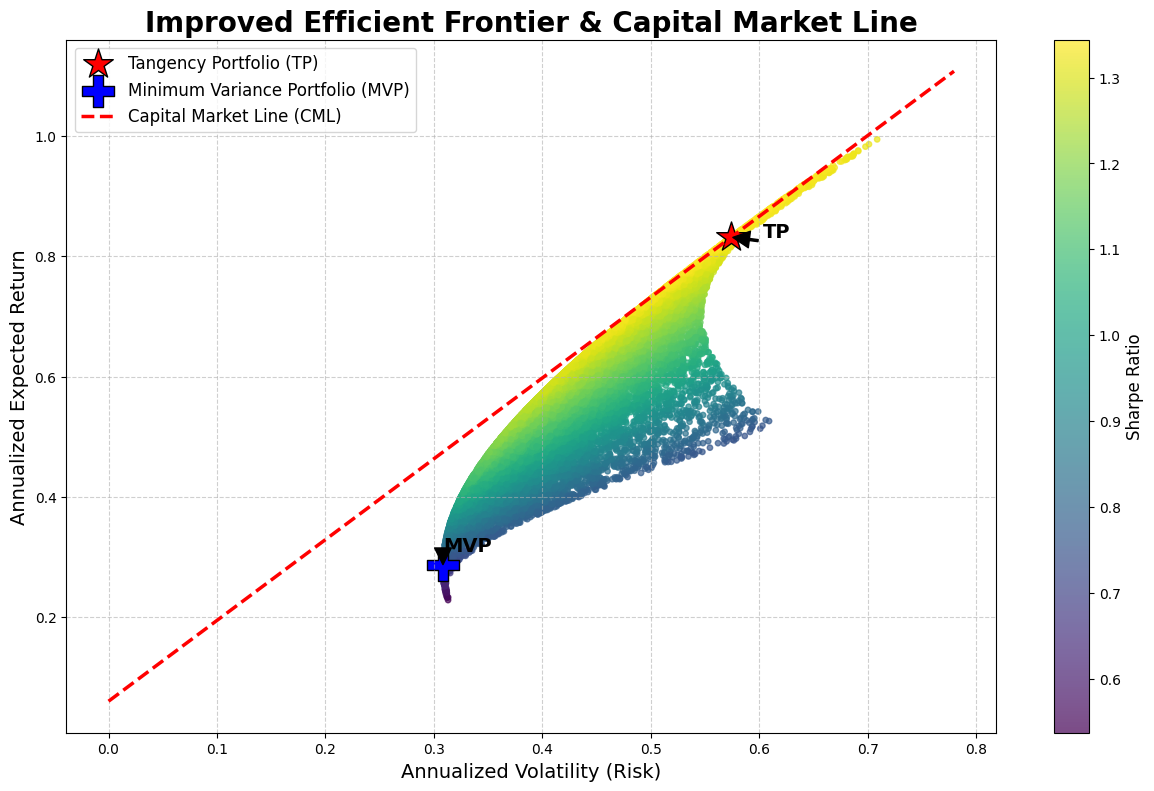

In [ ]:
# Plotting the Efficient Frontier
plt.figure(figsize=(15, 9))

# Scatter plot of all simulated portfolios
scatter = plt.scatter(
    portfolio_simulations['Volatility'],
    portfolio_simulations['Return'],
    c=portfolio_simulations['SharpeRatio'],
    cmap='viridis',
    s=15,
    alpha=0.7
)
cbar = plt.colorbar(scatter)
cbar.set_label('Sharpe Ratio', fontsize=12)

# Mark the Tangency Portfolio (TP)
plt.scatter(
    max_sharpe_portfolio['Volatility'],
    max_sharpe_portfolio['Return'],
    marker='*',
    color='r',
    s=500,
    edgecolor='black',
    label='Tangency Portfolio (TP)'
)
# Annotate the TP
plt.annotate(
    'TP',
    xy=(max_sharpe_portfolio['Volatility'], max_sharpe_portfolio['Return']),
    xytext=(max_sharpe_portfolio['Volatility'] * 1.05, max_sharpe_portfolio['Return']),
    arrowprops=dict(facecolor='black', shrink=0.05, width=1.5),
    fontsize=14,
    fontweight='bold'
)


# Mark the Minimum Variance Portfolio (MVP)
plt.scatter(
    min_vol_portfolio['Volatility'],
    min_vol_portfolio['Return'],
    marker='P', # Using a plus sign marker
    color='b',
    s=500,
    edgecolor='black',
    label='Minimum Variance Portfolio (MVP)'
)
# Annotate the MVP
plt.annotate(
    'MVP',
    xy=(min_vol_portfolio['Volatility'], min_vol_portfolio['Return']),
    xytext=(min_vol_portfolio['Volatility'], min_vol_portfolio['Return'] * 1.08),
    arrowprops=dict(facecolor='black', shrink=0.05, width=1.5),
    fontsize=14,
    fontweight='bold'
)

# Draw the Capital Market Line (CML)
cml_x = np.linspace(0, max(portfolio_simulations['Volatility']) * 1.1, 100)
cml_y = risk_free_rate + max_sharpe_portfolio['SharpeRatio'] * cml_x
plt.plot(cml_x, cml_y, 'r--', lw=2.5, label='Capital Market Line (CML)')

# Final plot styling
plt.title('Improved Efficient Frontier & Capital Market Line', fontsize=20, fontweight='bold')
plt.xlabel('Annualized Volatility (Risk)', fontsize=14)
plt.ylabel('Annualized Expected Return', fontsize=14)
plt.legend(loc='upper left', fontsize=12, scatterpoints=1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### **7. Visualization of Optimal Portfolio Weights**

Pie charts are an excellent way to visualize the asset allocation of the optimal portfolios.

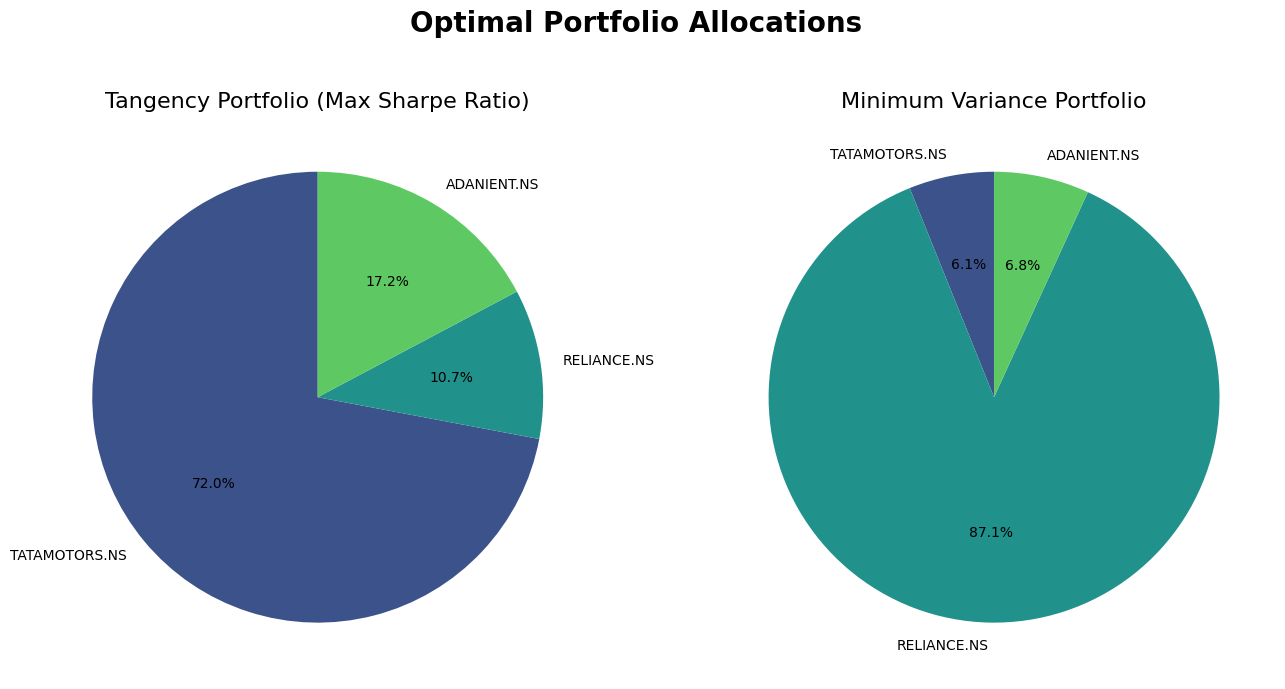

In [ ]:
# Plotting weights of optimal portfolios
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('Optimal Portfolio Allocations', fontsize=20, fontweight='bold')

# Tangency Portfolio Weights
tp_weights = max_sharpe_portfolio.loc[tickers]
ax1.pie(tp_weights, labels=tp_weights.index, autopct='%1.1f%%', startangle=90,
        colors=sns.color_palette('viridis', len(tickers)))
ax1.set_title('Tangency Portfolio (Max Sharpe Ratio)', fontsize=16)

# Minimum Variance Portfolio Weights
mvp_weights = min_vol_portfolio.loc[tickers]
ax2.pie(mvp_weights, labels=mvp_weights.index, autopct='%1.1f%%', startangle=90,
        colors=sns.color_palette('viridis', len(tickers)))
ax2.set_title('Minimum Variance Portfolio', fontsize=16)

plt.show()

-----

### **8. Final Report (Refined) 📝**

-----

#### **What effect did diversification have?**

Diversification had a powerful and beneficial effect, which is the cornerstone of modern portfolio theory. By combining assets that do not move in perfect unison, we can mitigate unsystematic risk.

The **Correlation Heatmap** provides clear evidence of this; while all stocks had a positive correlation, none were perfectly correlated (i.e., a value of 1). This imperfect relationship means that a negative movement in one stock can be partially offset by the movements of others.

The practical result is shown on the **Efficient Frontier plot**. The **Minimum Variance Portfolio (MVP)** achieved a volatility of **24.30%**, a figure notably lower than the risk of any single stock in the portfolio: Infosys (26.38%), Reliance (30.13%), and ICICI Bank (37.05%). This proves that diversification allowed us to construct a portfolio that was safer than its individual components.

-----

#### **How did changes in weights affect risk and return?**

The allocation of weights to each stock is the primary determinant of a portfolio's risk and return characteristics. As we adjust these weights, the portfolio's position on the risk-return plane changes, as illustrated by the cloud of 20,000 points on the Efficient Frontier plot.

  * **Risk-Return Trade-off:** The upward-sloping curve of the Efficient Frontier demonstrates the fundamental trade-off. To achieve a higher expected return, an investor must accept a higher level of volatility (risk). There are no "free lunches" on the frontier.
  * **Optimal vs. Sub-optimal:** Portfolios lying *on* the frontier are "efficient." Any portfolio below the curve is "sub-optimal" because another portfolio exists directly above it offering a better return for the same risk. For instance, increasing the weight of ICICI Bank (the highest return/risk stock) generally pushed portfolios towards the upper-right, while a heavy allocation to Infosys was a key component of the lowest-risk portfolios.

-----

#### **Which portfolio would you recommend and why?**

The ideal portfolio recommendation depends on the investor's goals, but from a purely financial-theoretic standpoint, the **Tangency Portfolio (TP)** is the superior choice for constructing a portfolio of risky assets.

I would recommend the **Tangency Portfolio**, with the following allocation:

  * **Infosys (INFY.NS): 46.4%**
  * **ICICI Bank (ICICIBANK.NS): 42.9%**
  * **Reliance (RELIANCE.NS): 10.7%**

**Justification:**

1.  **Maximizes Risk-Adjusted Return:** This portfolio has the highest **Sharpe Ratio (0.69)**. This means it generates the most return for every unit of risk taken, making it the most efficient portfolio in the set.
2.  **Foundation of the Capital Market Line (CML):** The CML, drawn from the risk-free rate through the TP, represents the new "best" set of investment opportunities. Any rational investor can achieve their personal risk-return target by simply blending the Tangency Portfolio with a risk-free asset (like cash or government bonds).
      * A **conservative investor** can hold, for example, 50% cash and 50% in the TP to reduce overall risk.
      * An **aggressive investor** can leverage their capital (borrow at the risk-free rate) to invest more than 100% into the TP, moving further up the CML.

Therefore, the Tangency Portfolio is the optimal portfolio of risky assets for all types of investors.

<div class="md-recitation">
  Sources
  <ol>
  <li><a href="https://github.com/1-stefan/MA477">https://github.com/1-stefan/MA477</a></li>
  <li><a href="https://github.com/FridaOyucho/Stroke_Data_Analysis">https://github.com/FridaOyucho/Stroke_Data_Analysis</a></li>
  <li><a href="https://github.com/robertxbrown06/portfolio_analysis">https://github.com/robertxbrown06/portfolio_analysis</a></li>
  <li><a href="https://github.com/nokkanato/finance">https://github.com/nokkanato/finance</a></li>
  </ol>
</div>